# 11-07-2026 Linear Regression Assignment
## Energy Efficiency Dataset
**Target:** Y1 (Heating Load)

Saving ENB2012_data.csv to ENB2012_data.csv
(768, 10)
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None
               X1          X2          X3          X4         X5          X6  \
count  768.000000  768.000000  768.000000  768.000000  768.00000  768.000000   
mean     0.764167  671.708333  318.500000  176.604167    5.25000    3.500000   
std      0.105777

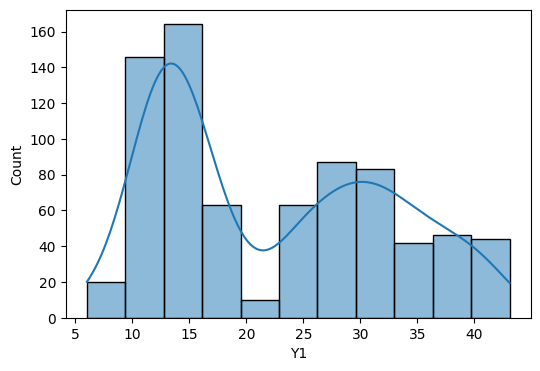

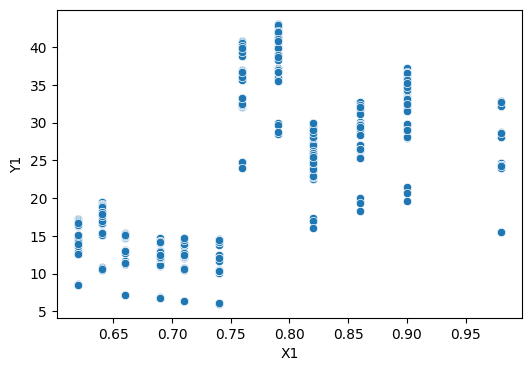

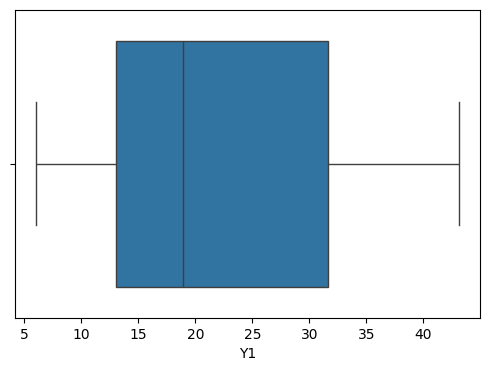

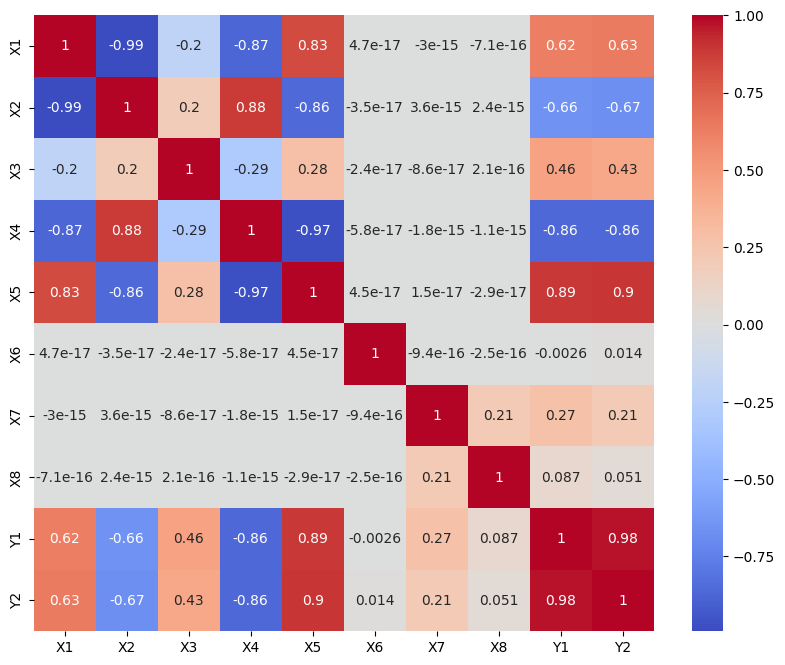

MAE : 2.182047022127921
MSE : 9.153187855202757
RMSE: 3.0254235827736182
R2 Score: 0.9121840951546909


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import files
uploaded=files.upload()
filename=list(uploaded.keys())[0]
df=pd.read_csv(filename)
df.head()
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())

plt.figure(figsize=(6,4))
sns.histplot(df["Y1"],kde=True)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="X1",y="Y1")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Y1"])
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

X=df[['X1','X2','X3','X4','X5','X6','X7','X8']]
y=df['Y1']

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)



## Generalisations

- Each row represents one building.
- X1-X8 are building design features.
- Y1 is Heating Load.
- Y2 is Cooling Load.
- Building design affects heating and cooling requirements.



## Feature Relationships

- Relative Compactness influences heating load.
- Surface Area affects energy efficiency.
- Wall Area and Roof Area affect insulation.
- Glazing Area impacts heat transfer.
- Overall Height influences energy demand.



## Feature Engineering

No additional feature engineering was required because the dataset already contains meaningful engineered features describing the building characteristics.



## Error Analysis

- **MAE**: Average prediction error. Lower is better.
- **MSE**: Penalizes larger errors more strongly.
- **RMSE**: Error in the same units as Heating Load.
- **R² Score**: Closer to 1 indicates a better fit.



## Conclusion

- Imported the Energy Efficiency dataset.
- Explored and analysed all features.
- Verified there were no missing values.
- Visualized the dataset using Seaborn.
- Applied StandardScaler.
- Split the data into training and testing sets.
- Trained a Linear Regression model.
- Evaluated the model using MAE, MSE, RMSE and R² Score.
- The model predicts Heating Load based on building characteristics.
